**Import Libraries (Markdown/Code)**

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

**Cell 2: Load the Dataset**

In [3]:
# Load the dataset from the data directory
df = pd.read_excel('/content/Week 2 (DataSet).xlsx')

# Display the first few rows
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


**Cell 3: Basic Data Information**

In [4]:
# Check data types and missing values
print(df.info())

# Check summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


Cell 4: Target Variable Distribution

/tmp/ipykernel_1355/2053223180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Load_Type', palette='viridis')


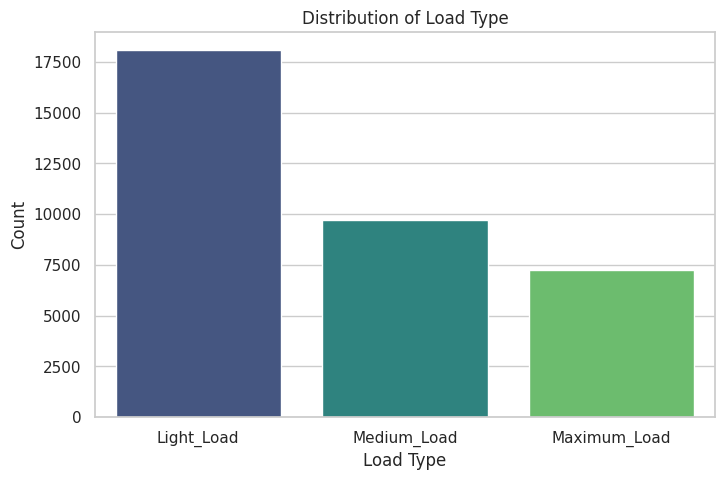

In [5]:
# Visualize the distribution of the target variable 'Load_Type'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Load_Type', palette='viridis')
plt.title('Distribution of Load Type')
plt.xlabel('Load Type')
plt.ylabel('Count')
plt.show()

Cell 5: Univariate Analysis (Energy Usage)

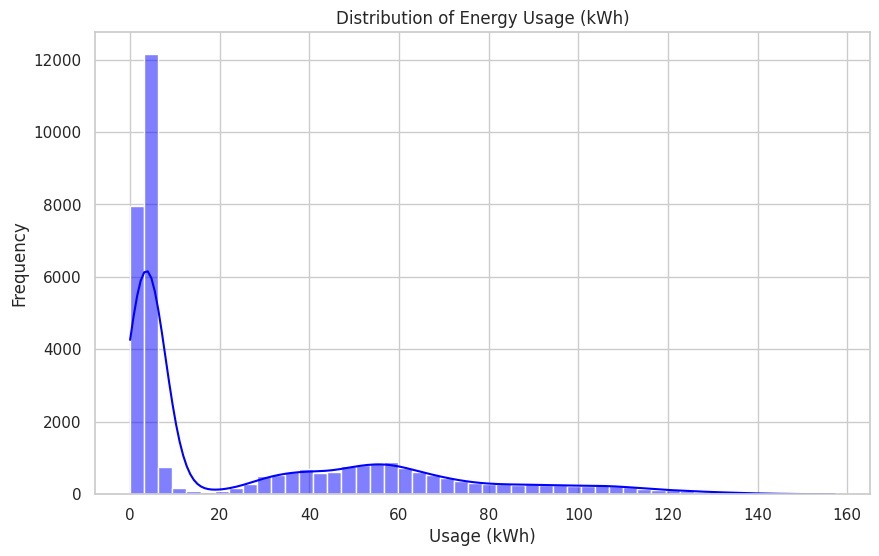

In [6]:
# Distribution of Usage_kWh
plt.figure(figsize=(10, 6))
sns.histplot(df['Usage_kWh'], bins=50, kde=True, color='blue')
plt.title('Distribution of Energy Usage (kWh)')
plt.xlabel('Usage (kWh)')
plt.ylabel('Frequency')
plt.show()

Cell 6: Bivariate Analysis (Usage vs. Week Status)

/tmp/ipykernel_1355/3380697015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='WeekStatus', y='Usage_kWh', palette='Set2')


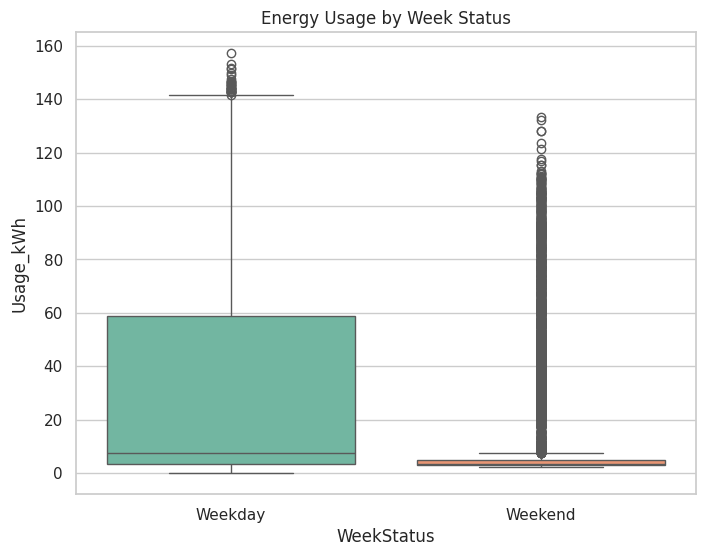

In [7]:
# Boxplot comparing usage between weekdays and weekends
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='WeekStatus', y='Usage_kWh', palette='Set2')
plt.title('Energy Usage by Week Status')
plt.show()

Cell 7: Correlation Matrix

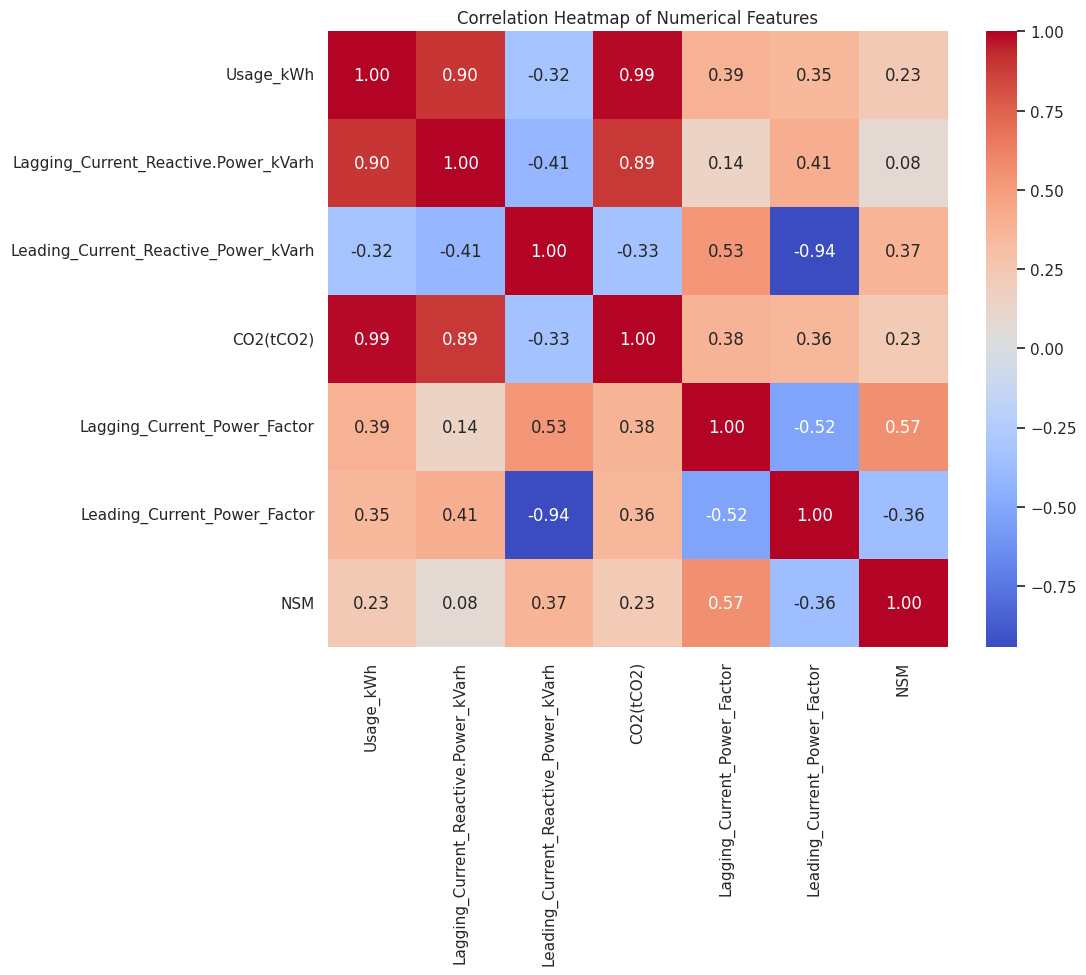

In [8]:
# Select only numerical features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Cell 1: Import Libraries for Modeling

In [9]:
# Import libraries for preprocessing, modeling, and evaluation
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Cell 2: Load and Prepare Data

In [10]:
# Load dataset
df = pd.read_excel('/content/Week 2 (DataSet).xlsx')

# Drop the date column as it requires time-series specific handling
df = df.drop('date', axis=1)

Cell 3: Feature Engineering & Preprocessing

In [11]:
# Separate features (X) and target (y)
X = df.drop('Load_Type', axis=1)
y = df['Load_Type']

# One-Hot Encode categorical features
X = pd.get_dummies(X, columns=['WeekStatus', 'Day_of_week'], drop_first=True)

# Label Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

Cell 4: Train-Test Split & Scaling

In [12]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cell 5: Model 1 - Logistic Regression

In [13]:
# Initialize and train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7604166666666666


Cell 6: Model 2 - K-Nearest Neighbors (KNN)

In [14]:
# Initialize and train KNN (using k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8585901826484018


Cell 7: Model 3 - Random Forest Classifier

In [15]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.908675799086758


Cell 8: Final Evaluation & Confusion Matrix

Random Forest Classification Report:

              precision    recall  f1-score   support

  Light_Load       0.98      0.98      0.98      3615
Maximum_Load       0.83      0.83      0.83      1454
 Medium_Load       0.84      0.84      0.84      1939

    accuracy                           0.91      7008
   macro avg       0.88      0.88      0.88      7008
weighted avg       0.91      0.91      0.91      7008



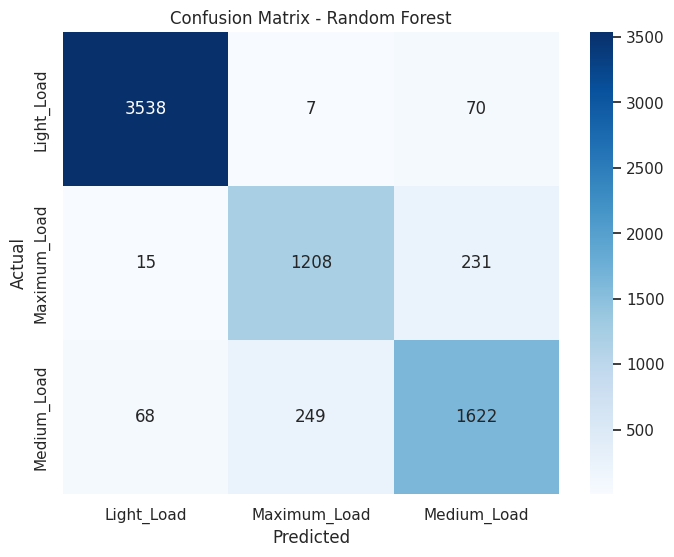

In [16]:
# Print full classification report for the best model (typically Random Forest here)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()